# MIMII Dataset Inspection

Initial inspection of MIMII fan recordings.

Machine type: Fan  
Machine ID: id_00  
Condition: 0 dB  
Classes: Normal / Abnormal

In [49]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from IPython.display import Audio, display

Sampling rate:  16000
Number of samples:  160000
Duration: 10.0 seconds


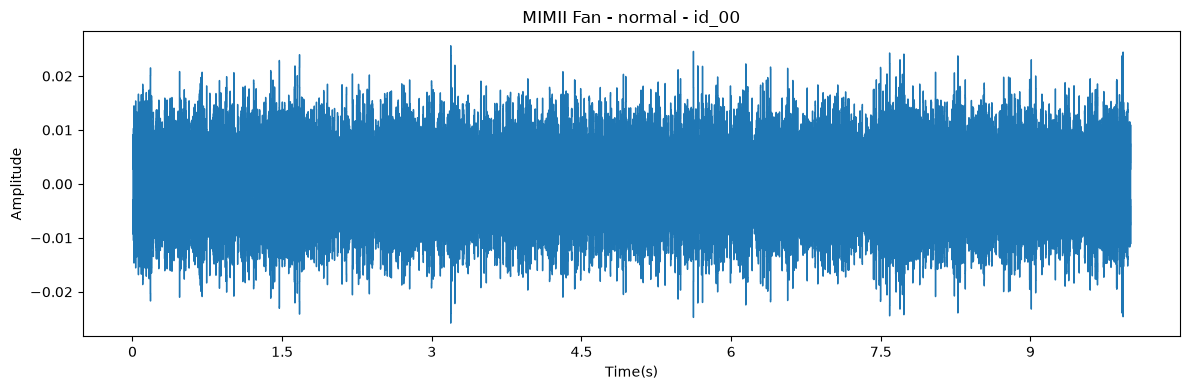

In [50]:
audio_path = "C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/normal/00000000.wav"
y, sr = librosa.load(audio_path, sr = None)
print("Sampling rate: ",sr)
print("Number of samples: ",len(y))
print(f"Duration: {len(y)/sr} seconds")
plt.figure(figsize = (12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("MIMII Fan - normal - id_00")
plt.xlabel("Time(s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

Sampling rate:  16000
Number of samples:  160000
Duration: 10.0 seconds


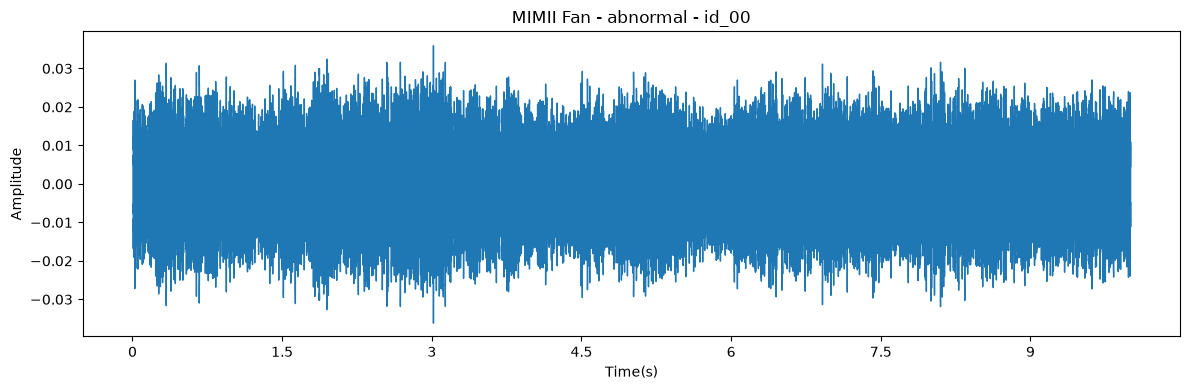

In [51]:
audio_path = "C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/abnormal/00000000.wav"
y, sr = librosa.load(audio_path, sr = None)
print("Sampling rate: ",sr)
print("Number of samples: ",len(y))
print(f"Duration: {len(y)/sr} seconds")
plt.figure(figsize = (12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("MIMII Fan - abnormal - id_00")
plt.xlabel("Time(s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [52]:
data_root = Path("C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00")
records = []

for label in ['normal','abnormal']:
    folder = data_root/label

    for audio_file in sorted(folder.glob('*.wav'))[:6]:
        y, sr = librosa.load(audio_file, sr = None)

        records.append({
            'file':audio_file.name,
            'label':label,
            'sampling_rate':sr,
            'samples':len(y),
            'sampling duration(s)': len(y)/sr
        }

        )

df = pd.DataFrame(records)
print(df)

            file     label  sampling_rate  samples  sampling duration(s)
0   00000000.wav    normal          16000   160000                  10.0
1   00000001.wav    normal          16000   160000                  10.0
2   00000002.wav    normal          16000   160000                  10.0
3   00000003.wav    normal          16000   160000                  10.0
4   00000004.wav    normal          16000   160000                  10.0
5   00000005.wav    normal          16000   160000                  10.0
6   00000000.wav  abnormal          16000   160000                  10.0
7   00000001.wav  abnormal          16000   160000                  10.0
8   00000002.wav  abnormal          16000   160000                  10.0
9   00000003.wav  abnormal          16000   160000                  10.0
10  00000004.wav  abnormal          16000   160000                  10.0
11  00000005.wav  abnormal          16000   160000                  10.0


In [53]:
normal_path = 'C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/normal/00000000.wav'
abnormal_path = "C:/Users/Deep/Desktop/Deep/Projects/Acoustic machine fault detection/acoustic-machine-fault-detection/data/raw/fan/id_00/abnormal/00000000.wav"

display(Audio(normal_path))
display(Audio(abnormal_path))

In [54]:
normal_y, _ = librosa.load(normal_path, sr = None)
abnormal_y, _ = librosa.load(abnormal_path, sr = None)

print("Normal")
print("RMS: ",librosa.feature.rms(y=normal_y).mean())
print(f"Peak: {abs(normal_y.max())}")

print("Abnormal")
print(f"RMS: {librosa.feature.rms(y=abnormal_y).mean()}")
print(f"Peak: {abs(abnormal_y.max())}")

Normal
RMS:  0.0061088228
Peak: 0.024658203125
Abnormal
RMS: 0.009899850934743881
Peak: 0.03125


###Observations

-Recordings have a sampling rate of 16Khz.
-Each recording is 10 seconds long.
-Example waveforms from normal and abnormal have visibly different waveform amplitude patterns.
-Visual observation alone is not sufficient to conclude anything.
-Further analysis in frequency domain is required.